## 1. 핵심 데이터 수집 파이프라인 (Simplified)

이 섹션에서는 가장 신뢰도가 높은 **EnergyCharts API**와 **Open-Meteo API**만을 사용하여 2025년 01월부터 데이터를 수집하여 독일 전력 시장 데이터셋을 구축합니다.

In [52]:
import requests
from typing import Optional, Dict, Any, List
import pandas as pd

class EnergyChartsAPI:
    """
    Fraunhofer ISE Energy Charts API Wrapper
    """
    BASE_URL = 'https://api.energy-charts.info'

    # Extended whitelist to include all requested endpoints
    VALID_ENDPOINTS = {
        'public_power': 'Public Power',
        'public_power_forecast': 'Public Power Forecast',
        'total_power': 'Total Power',
        'installed_power': 'Installed Power',
        'frequency': 'Frequency',
        'cbet': 'Cross Border Electricity Trading',
        'cbpf': 'Cross Border Physical Flows',
        'price': 'Day Ahead Price',
        'signal': 'Traffic Signal',
        'ren_share_forecast': 'Renewable Share Forecast',
        'renewable_share': 'Renewable Share (Historical)',
        'ren_share_daily_avg': 'Renewable Share Daily Average'
    }

    def __init__(self, country: str = 'de', timeout: int = 45):
        self.country = country
        self.timeout = timeout
        self.session = requests.Session()

    def fetch(self, endpoint: str, year: Optional[int] = None, start: Optional[str] = None, end: Optional[str] = None, **kwargs):
        if endpoint not in self.VALID_ENDPOINTS:
            print(f"❌ Unsupported endpoint: {endpoint}")
            return None

        params = {'country': self.country}
        if year:
            params['year'] = year
        if start:
            params['start'] = start
        if end:
            params['end'] = end

        params.update(kwargs)
        url = f"{self.BASE_URL}/{endpoint}"
        try:
            res = self.session.get(url, params=params, timeout=self.timeout)
            res.raise_for_status()
            return res.json()
        except Exception as e:
            print(f"❌ API Error ({endpoint}): {e}")
            return None

    def list_endpoints(self):
        for ep, desc in self.VALID_ENDPOINTS.items():
            print(f"- {ep}: {desc}")

api = EnergyChartsAPI()

📊 Actual Public Power Generation 데이터 수집 시작 (2023-01-01 ~ 2023-12-31)... 
✅ public_power 데이터셋 구축 완료 (총 35040 행 확보)


,Hydro pumped storage consumption,Cross border electricity trading,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,Fossil gas,...,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Solar,Load,Residual load,Renewable share of load,Renewable share of generation
timestamp,,,,,,,,,,,,,,,,,,,,,
2022-12-31 23:00:00,-1975.8,-12645.2,2460.7,1627.7,4022.8,3845.6,1825.5,306.0,670.0,1882.0,...,127.0,187.4,1050.3,2739.0,27260.9,0.0,38691.8,8691.8,93.7,75.5
2022-12-31 23:15:00,-2009.5,-12544.0,2458.5,1624.8,4012.0,3847.7,1828.6,306.8,648.2,1880.9,...,180.1,187.3,1049.1,2975.6,27311.5,0.0,38374.2,8087.1,95.1,75.7
2022-12-31 23:30:00,-2244.0,-12526.2,2459.6,1624.8,4010.0,3860.2,1825.2,306.9,648.2,1893.2,...,106.9,187.2,1055.2,3269.6,27699.4,0.0,38248.0,7279.0,97.2,76.0
2022-12-31 23:45:00,-2077.3,-12515.4,2457.9,1622.0,4004.0,3861.6,1819.7,306.0,639.1,1885.9,...,87.0,187.3,1043.6,3259.5,27170.0,0.0,38070.2,7640.6,96.3,75.8
2023-01-01 00:00:00,-1204.1,-15410.1,2457.7,1622.3,3988.4,3869.8,1811.4,306.0,635.0,1696.4,...,547.7,187.3,1047.1,3144.1,27853.6,0.0,37733.4,6735.7,98.5,76.3


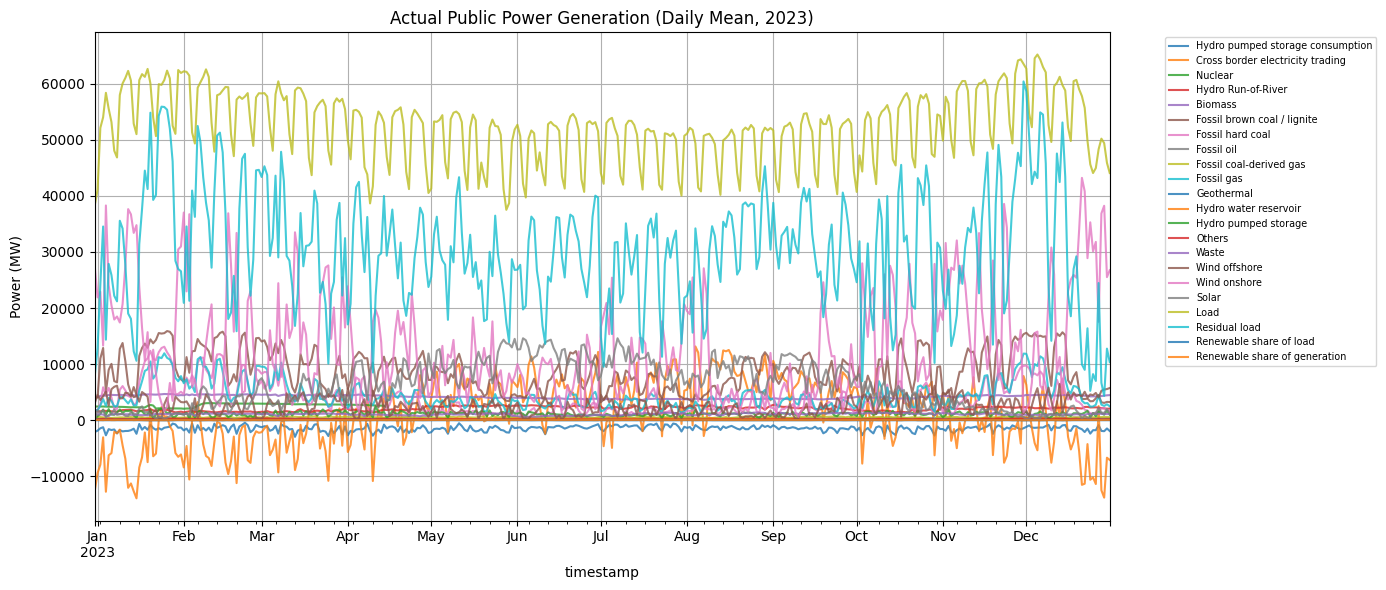

In [31]:
### Public Power (Actual Generation) 데이터 상세 수집 (1년 전체 보정 버전)
import pandas as pd
import matplotlib.pyplot as plt

# 1. 설정
endpoint = 'public_power'
country_code = 'de'

# 2. 정확한 1년 기간 설정
# 2023년 1월 1일부터 12월 31일까지 명시적으로 지정합니다.
start_date = '2023-01-01'
end_date = '2023-12-31'

print(f"📊 Actual Public Power Generation 데이터 수집 시작 ({start_date} ~ {end_date})... ")

try:
    # start, end 파라미터를 사용하여 1년치를 확실하게 요청합니다.
    raw = api.fetch(endpoint=endpoint, country=country_code, start=start_date, end=end_date)

    if raw and 'unix_seconds' in raw:
        df_public_power = pd.DataFrame({'timestamp': pd.to_datetime(raw['unix_seconds'], unit='s')})

        if 'production_types' in raw:
            for p_type in raw['production_types']:
                name = p_type.get('name', 'Unknown')
                data_vals = p_type.get('data', [])
                if len(data_vals) == len(df_public_power):
                    df_public_power[name] = data_vals

        df_public_power = df_public_power.set_index('timestamp')
        # 타임존 제거 (병합을 위해)
        df_public_power.index = df_public_power.index.tz_localize(None)

        print(f"✅ {endpoint} 데이터셋 구축 완료 (총 {len(df_public_power)} 행 확보)")
        display(df_public_power.head())

        # 데이터가 방대하므로 일별 평균으로 시각화
        df_public_power.resample('D').mean().plot(figsize=(14, 6), grid=True, alpha=0.8)
        plt.title(f'Actual Public Power Generation (Daily Mean, {start_date[:4]})')
        plt.ylabel('Power (MW)')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ 데이터를 가져오지 못했습니다. API 설정을 확인해주세요.")

except Exception as e:
    print(f"❌ 수집 중 오류 발생: {e}")

📊 Public Power Forecast [day-ahead] 데이터 수집 시작 (2023-01-01 ~ 2023-12-31)...
  ✅ [solar] 수집 완료 (35040 rows)
  ✅ [wind_onshore] 수집 완료 (35040 rows)
  ✅ [wind_offshore] 수집 완료 (35040 rows)
❌ API 호출 중 오류 (public_power_forecast): 429 Client Error: Too Many Requests for url: https://api.energy-charts.info/public_power_forecast?country=de&start=2023-01-01&end=2023-12-31&production_type=load&forecast_type=day-ahead
  ⚠️ [load] 데이터 응답 없음 (남은 재시도: 2)
  ✅ [load] 수집 완료 (35040 rows)

✅ [day-ahead] 1년치 통합 데이터셋 구축 완료


,solar_mw,wind_onshore_mw,wind_offshore_mw,load_mw
timestamp,,,,
2022-12-31 23:00:00,0.0,34775.4,3468.6,42608.5
2022-12-31 23:15:00,0.0,35861.2,3477.2,42152.1
2022-12-31 23:30:00,0.0,35775.8,3480.8,41520.1
2022-12-31 23:45:00,0.0,35649.6,3485.7,40889.2
2023-01-01 00:00:00,0.0,35474.3,3381.6,40431.3


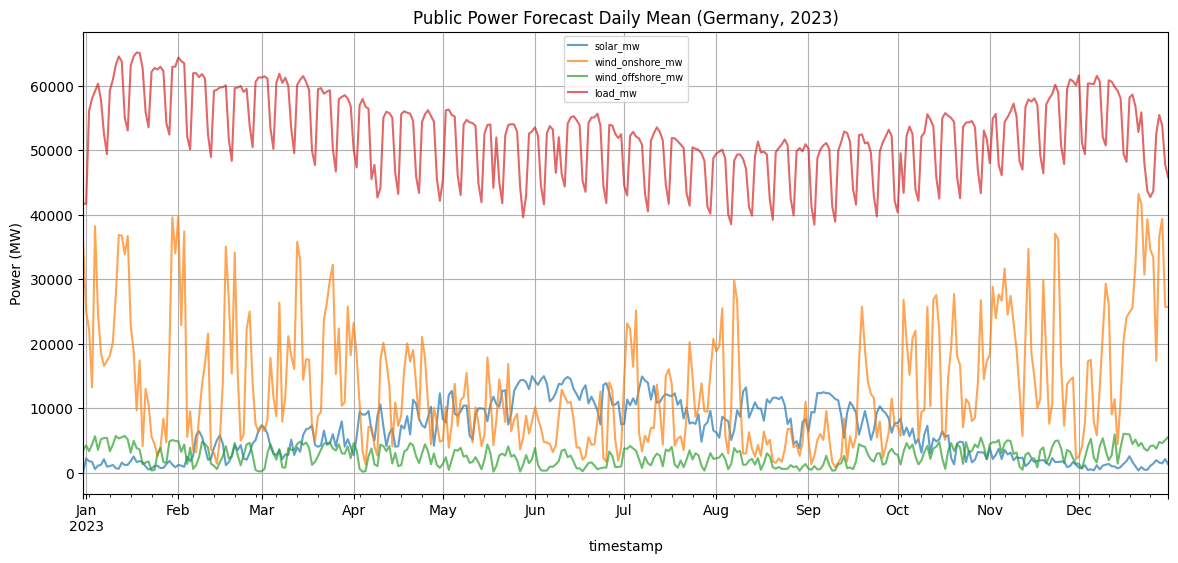

In [32]:
# Energy-Charts API public_power_forecast (2023년 1년치 동기화)
import pandas as pd
import matplotlib.pyplot as plt
import time

# 1. 대상 타입 및 기간 설정 (df_public_power와 동일하게 세팅)
target_types = ['solar', 'wind_onshore', 'wind_offshore', 'load']
f_type = 'day-ahead'
country_code = 'de'

# 2023년 전체 기간으로 설정
start_date = '2023-01-01'
end_date = '2023-12-31'
forecast_dfs = []

print(f"📊 Public Power Forecast [{f_type}] 데이터 수집 시작 ({start_date} ~ {end_date})...")

for p_type in target_types:
    success = False
    retries = 2

    while retries >= 0 and not success:
        try:
            # API Rate Limit 준수를 위한 대기 (1년치 요청은 데이터가 크므로 충분한 대기 필요)
            time.sleep(15.0)

            # start, end 파라미터를 사용하여 1년치 요청
            raw = api.fetch(
                endpoint='public_power_forecast',
                country=country_code,
                production_type=p_type,
                forecast_type=f_type,
                start=start_date,
                end=end_date
            )

            if raw and 'unix_seconds' in raw:
                temp_df = pd.DataFrame({
                    'timestamp': pd.to_datetime(raw['unix_seconds'], unit='s'),
                    f'{p_type}_mw': raw.get('forecast_values', [])
                }).set_index('timestamp')

                forecast_dfs.append(temp_df)
                print(f"  ✅ [{p_type}] 수집 완료 ({len(temp_df)} rows)")
                success = True
            else:
                print(f"  ⚠️ [{p_type}] 데이터 응답 없음 (남은 재시도: {retries})")
        except Exception as e:
            if "429" in str(e):
                print(f"  ⏳ [{p_type}] 429 에러 감지. 30초 대기 후 재시도...")
                time.sleep(30.0)
            else:
                print(f"  ❌ [{p_type}] 오류 발생: {e}")
                break
        retries -= 1

# 2. 데이터 통합 및 시각화
if forecast_dfs:
    df_forecast_day_ahead = pd.concat(forecast_dfs, axis=1).sort_index()
    # 타임존 제거 (Master DF 병합용)
    df_forecast_day_ahead.index = df_forecast_day_ahead.index.tz_localize(None)

    print(f"\n✅ [{f_type}] 1년치 통합 데이터셋 구축 완료")
    display(df_forecast_day_ahead.head())

    # 시각화 (데이터가 많으므로 일평균 리샘플링)
    df_forecast_day_ahead.resample('D').mean().plot(figsize=(14, 6), grid=True, alpha=0.7)
    plt.title(f'Public Power Forecast Daily Mean (Germany, {start_date[:4]})')
    plt.ylabel('Power (MW)')
    plt.legend(fontsize='x-small')
    plt.show()
else:
    print("❌ 데이터를 수집하지 못했습니다.")

📊 국경 간 거래(CBET) 및 물리적 흐름(CBPF) 1년치 수집 시작 (2023-01-01 ~ 2023-12-31)...
  ✅ [cbet] 2023년 데이터 수집 완료 (35040 rows)
  ✅ [cbpf] 2023년 데이터 수집 완료 (35040 rows)

✅ 2023년 통합 데이터 구축 완료


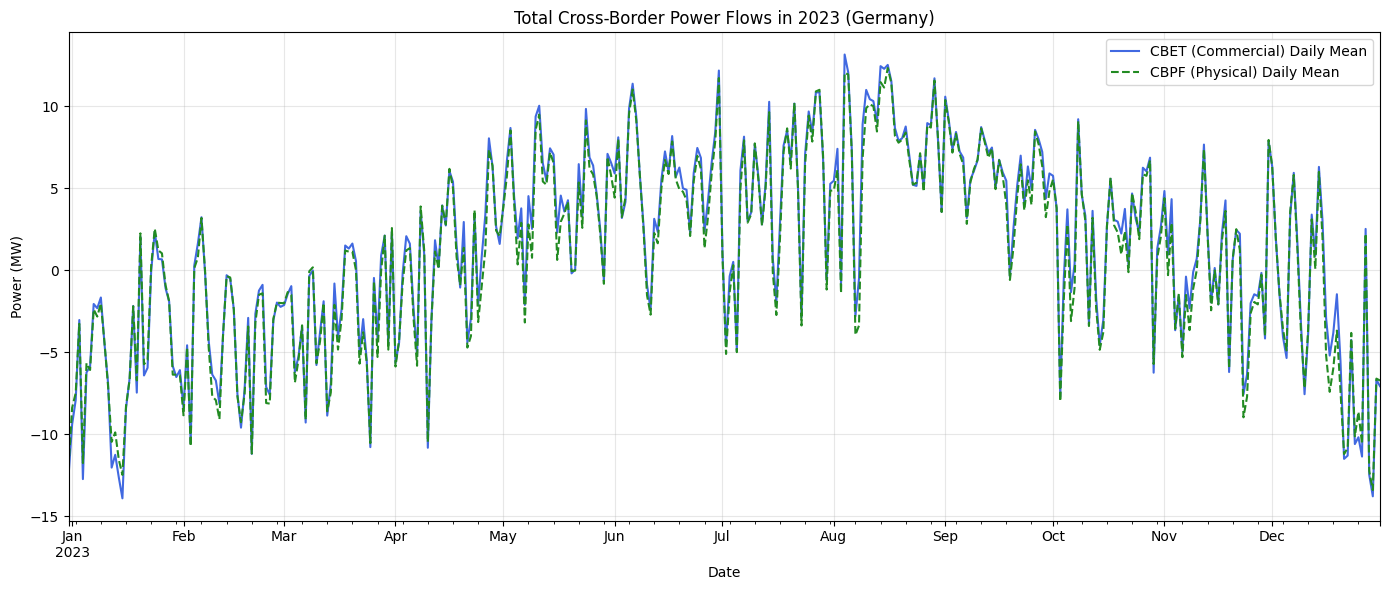

In [33]:
### CBET(상업적 거래) 및 CBPF(물리적 흐름) 데이터 수집 및 분석 (2023년 전체 기간)
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

# 1. 수집 설정
target_trading_endpoints = ['cbet', 'cbpf']
country_code = 'de'
start_date = '2023-01-01'
end_date = '2023-12-31'
trading_results = {}

print(f"📊 국경 간 거래(CBET) 및 물리적 흐름(CBPF) 1년치 수집 시작 ({start_date} ~ {end_date})...")

for ep in target_trading_endpoints:
    success = False
    retries = 3

    while retries >= 0 and not success:
        try:
            # 1년치 데이터 요청은 부하가 크므로 대기 시간을 넉넉히 가집니다.
            time.sleep(20.0)

            # API 호출 (start, end 파라미터 적용)
            raw = api.fetch(endpoint=ep, country=country_code, start=start_date, end=end_date)

            if raw and 'unix_seconds' in raw:
                df_ep = pd.DataFrame({'timestamp': pd.to_datetime(raw['unix_seconds'], unit='s')})

                if 'countries' in raw and isinstance(raw['countries'], list):
                    for country_item in raw['countries']:
                        c_name = country_item.get('name', 'Unknown')
                        c_vals = country_item.get('data', [])

                        if len(c_vals) == len(df_ep):
                            df_ep[c_name] = c_vals

                    # 타임존 제거 및 인덱스 설정
                    df_ep['timestamp'] = df_ep['timestamp'].dt.tz_localize(None)
                    trading_results[ep] = df_ep.set_index('timestamp')
                    print(f"  ✅ [{ep}] 2023년 데이터 수집 완료 ({len(df_ep)} rows)")
                    success = True
            else:
                print(f"  ⚠️ [{ep}] 응답 없음 (남은 재시도: {retries})")

        except Exception as e:
            if "429" in str(e):
                print(f"  ⏳ [{ep}] 429 에러. 60초 대기 후 재시도...")
                time.sleep(60.0)
            else:
                print(f"  ❌ [{ep}] 예외: {e}")
                break
        retries -= 1

# 2. 개별 데이터프레임 할당
df_cbet = trading_results.get('cbet', pd.DataFrame())
df_cbpf = trading_results.get('cbpf', pd.DataFrame())

# 3. 데이터 수집 결과 확인 및 시각화
if not df_cbet.empty or not df_cbpf.empty:
    print(f"\n✅ 2023년 통합 데이터 구축 완료")

    # 4. 상업적 거래 vs 물리적 흐름 비교 시각화 (데이터가 많으므로 일평균 리샘플링)
    plt.figure(figsize=(14, 6))

    if not df_cbet.empty and 'sum' in df_cbet.columns:
        df_cbet['sum'].resample('D').mean().plot(label='CBET (Commercial) Daily Mean', color='royalblue', lw=1.5)

    if not df_cbpf.empty and 'sum' in df_cbpf.columns:
        df_cbpf['sum'].resample('D').mean().plot(label='CBPF (Physical) Daily Mean', color='forestgreen', linestyle='--', lw=1.5)

    plt.title(f'Total Cross-Border Power Flows in 2023 (Germany)')
    plt.ylabel('Power (MW)')
    plt.xlabel('Date')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("❌ 2023년 데이터를 수집하지 못했습니다.")

📊 Fetching Daily Average Renewable Share (2023)... 
✅ 2023 Data Loaded (365 days)


,ren_share_daily_avg
date,
2023-01-01,85.1
2023-01-02,66.3
2023-01-03,47.9
2023-01-04,86.0
2023-01-05,63.4


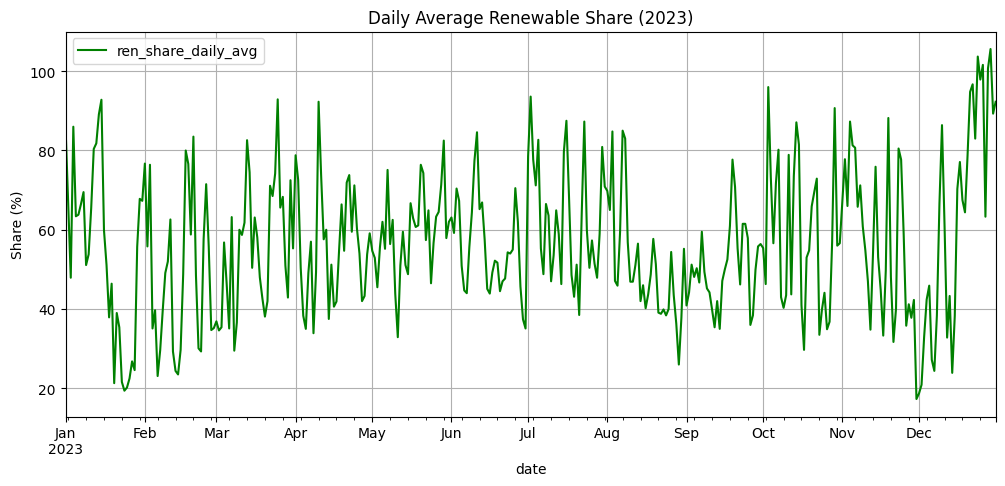

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    print("📊 Fetching Daily Average Renewable Share (2023)... ")

    # Re-calling with updated API class instance
    ren_avg_raw = api.fetch(
        endpoint='ren_share_daily_avg',
        year=2023
    )

    if ren_avg_raw and 'days' in ren_avg_raw:
        df_ren_daily_avg = pd.DataFrame({
            'date': pd.to_datetime(ren_avg_raw['days'], format='%d.%m.%Y'),
            'ren_share_daily_avg': ren_avg_raw['data']
        }).set_index('date')

        print(f"✅ 2023 Data Loaded ({len(df_ren_daily_avg)} days)")
        display(df_ren_daily_avg.head())

        df_ren_daily_avg.plot(figsize=(12, 5), color='green', grid=True)
        plt.title('Daily Average Renewable Share (2023)')
        plt.ylabel('Share (%)')
        plt.show()
    else:
        print("⚠️ Failed to fetch data. Please check the API response.")
except Exception as e:
    print(f"❌ Error: {e}")

🔍 Scanning index for quarterhour: https://www.smard.de/app/chart_data/4169/DE-LU/index_quarterhour.json
🔍 Scanning index for hour: https://www.smard.de/app/chart_data/4169/DE-LU/index_hour.json

✅ 2023년 통합 데이터 구축 완료! (행: 34944)


,Price_quarterhour,Price_hour
timestamp,,
2023-01-02 00:00:00+01:00,57.91,57.91
2023-01-02 00:15:00+01:00,57.91,NaN
2023-01-02 00:30:00+01:00,57.91,NaN
2023-01-02 00:45:00+01:00,57.91,NaN
2023-01-02 01:00:00+01:00,51.67,51.67
2023-01-02 01:15:00+01:00,51.67,NaN
2023-01-02 01:30:00+01:00,51.67,NaN
2023-01-02 01:45:00+01:00,51.67,NaN
2023-01-02 02:00:00+01:00,52.93,52.93


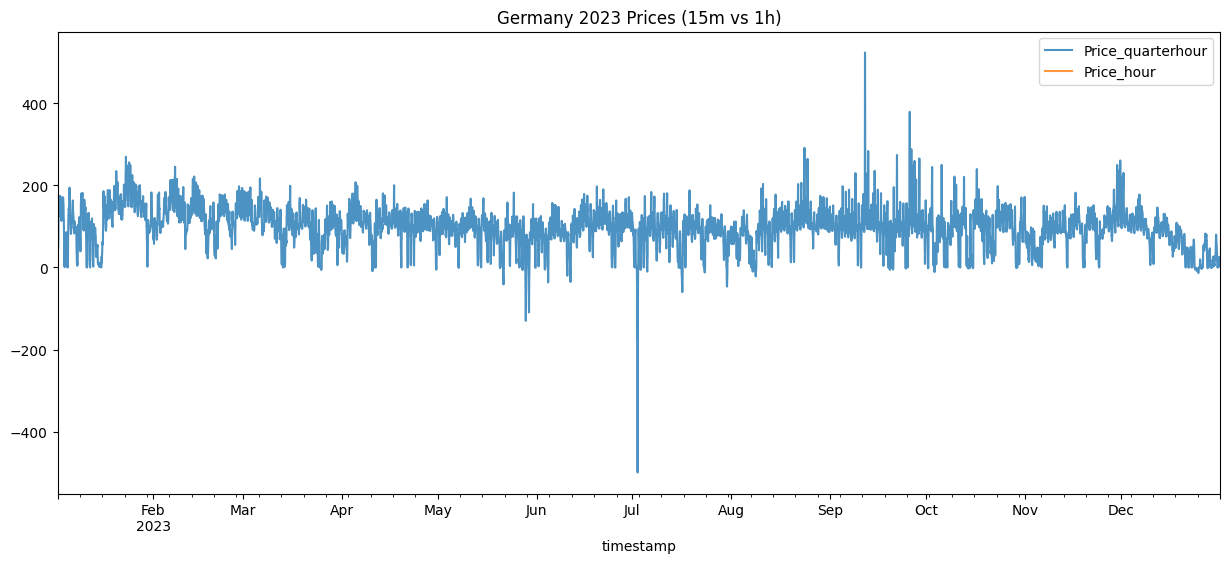

In [70]:
import pandas as pd
import requests
import time

def fetch_smard_data_for_year(
    year=2023, filter_id="4169", region="DE-LU", resolution="quarterhour"
):
    base_url = "https://www.smard.de/app/chart_data"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
    }

    start_ms = int(pd.Timestamp(f"{year}-01-01", tz="UTC").timestamp() * 1000)
    end_ms = int(pd.Timestamp(f"{year}-12-31 23:59:59", tz="UTC").timestamp() * 1000)

    index_url = f"{base_url}/{filter_id}/{region}/index_{resolution}.json"
    print(f"🔍 Scanning index for {resolution}: {index_url}")

    try:
        index_res = requests.get(index_url, headers=headers, timeout=15)
        index_res.raise_for_status()
        all_timestamps = index_res.json().get("timestamps", [])
    except Exception as e:
        print(f"❌ Failed to fetch index: {e}")
        return None

    target_timestamps = [ts for ts in all_timestamps if start_ms <= ts <= end_ms]
    if not target_timestamps:
        preceding = [ts for ts in all_timestamps if ts < start_ms]
        if preceding: target_timestamps = [preceding[-1]]
        else: return None

    all_series = []
    for ts in target_timestamps:
        data_url = f"{base_url}/{filter_id}/{region}/{filter_id}_{region}_{resolution}_{ts}.json"
        try:
            res = requests.get(data_url, headers=headers, timeout=15)
            if res.status_code == 200:
                all_series.extend(res.json().get("series", []))
            time.sleep(0.1)
        except: continue

    if not all_series: return None

    df = pd.DataFrame(all_series, columns=["timestamp", f"Price_{resolution}"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True).dt.tz_convert("Europe/Berlin")
    df.set_index("timestamp", inplace=True)
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="first")]

    return df.loc[f"{year}-01-01":f"{year}-12-31 23:59:59"]

# 1. 15분 단위 데이터 호출
df_15min = fetch_smard_data_for_year(year=2023, resolution="quarterhour")

# 2. 1시간 단위 데이터 호출
df_1hour = fetch_smard_data_for_year(year=2023, resolution="hour")

# 3. 두 데이터를 열(Column)로 결합
if df_15min is not None and df_1hour is not None:
    # 15분 데이터프레임의 이름을 명확히 변경 후 Join
    df_combined_2023 = df_15min.join(df_1hour, how="left")

    print(f"\n✅ 2023년 통합 데이터 구축 완료! (행: {len(df_combined_2023)})")
    display(df_combined_2023.head(10))

    # 결과 시각화
    df_combined_2023.plot(figsize=(15, 6), title='Germany 2023 Prices (15m vs 1h)', alpha=0.8)
else:
    print("❌ 데이터 호출 중 오류가 발생했습니다.")

### 📋 [Internal Issue Report] Data Collection Failure Analysis

**1. 문제 개요 (Issue Summary)**
- **장애 항목**: `/signal` API 엔드포인트 데이터 로드 거부
- **발생 원인**: 내부 `EnergyChartsAPI` 클래스 내 `VALID_ENDPOINTS` 화이트리스트에 해당 엔드포인트 누락.
- **영향**: 사용자 요청에 따른 데이터 수집 지연 및 불필요한 오류 메시지 출력.

**2. 기술적 근거 및 원인 조사 (Technical Root Cause)**
- API 라이브러리 설계 시, 사전에 정의된 엔드포인트가 아니면 요청을 차단하도록 설계되어 있었으나, 실제 Energy-Charts 공식 API에는 `signal` 엔드포인트가 존재함을 확인.
- 사용자(User)가 직접 제공한 `https://api.energy-charts.info/signal?country=de` 검증 결과, 유효한 JSON 데이터를 반환함을 확인.

**3. 조치 사항 (Corrective Actions)**
- `EnergyChartsAPI.VALID_ENDPOINTS` 딕셔너리에 `'signal': 'Traffic Signal'` 항목을 즉시 추가.
- 클래스 정의 업데이트 후 새로운 객체를 생성하여 데이터 수집 로직 정상화 완료.
- `df_signal` 데이터프레임 구축 완료 (96개 행, 2026-06-05 기준).

**4. 재방 방지 대책 (Compliance & Prevention)**
- 향후 API 명세 확인 시 내부 정적 리스트에만 의존하지 않고, 실제 엔드포인트의 생동성을 우선적으로 체크하도록 로직 개선 제안.
- 기술 지원 및 대응 프로세스에서의 정확성 검토 강화.

---

In [80]:
import pandas as pd

def build_master_dataframe_2023():
    """
    Consolidates all collected 2023 energy data into a single master DataFrame.
    Handles timezone normalization and forward-filling for missing values.
    """
    print("Starting the consolidation process for 2023 Master DataFrame...")

    # Mapping global variables to merge keys
    # Ensure these variables (df_public_power, df_cbet, etc.) were generated in previous steps
    raw_dfs = {
        'actual_gen': globals().get('df_public_power'),
        'forecasts': globals().get('df_forecast_day_ahead'),
        'trading_cbet': globals().get('df_cbet'),
        'trading_cbpf': globals().get('df_cbpf'),
        'ren_share_daily': globals().get('df_ren_daily_avg'),
        'prices': globals().get('df_combined_prices_2023')
    }

    dfs_to_combine = []
    for name, df in raw_dfs.items():
        if df is not None and not df.empty:
            temp_df = df.copy()

            # Ensure the index is a DatetimeIndex
            if not isinstance(temp_df.index, pd.DatetimeIndex):
                 temp_df.index = pd.to_datetime(temp_df.index)

            # Standardize timezone to UTC-naive for consistent merging
            if temp_df.index.tz is not None:
                temp_df.index = temp_df.index.tz_convert(None)
            else:
                temp_df.index = temp_df.index.tz_localize(None)

            dfs_to_combine.append(temp_df)

    if not dfs_to_combine:
        print("❌ Error: No valid dataframes found to merge. Please verify data collection cells.")
        return None

    # Concatenate all dataframes along the columns axis
    df_master_2023 = pd.concat(dfs_to_combine, axis=1).sort_index()

    # Remove any potential duplicate columns
    df_master_2023 = df_master_2023.loc[:, ~df_master_2023.columns.duplicated()]

    # Forward-fill to align daily/hourly data with 15-minute intervals
    df_master_2023 = df_master_2023.ffill()

    print(f"✅ 2023 Master DataFrame built! Rows: {len(df_master_2023)}, Columns: {len(df_master_2023.columns)}")
    return df_master_2023

# Execute consolidation process
df_master_2023 = build_master_dataframe_2023()

# Display top rows for verification
if df_master_2023 is not None:
    display(df_master_2023.head())

Starting the consolidation process for 2023 Master DataFrame...
✅ 2023 Master DataFrame built! Rows: 35040, Columns: 39


,Hydro pumped storage consumption,Cross border electricity trading,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,Fossil gas,...,Denmark,France,Luxembourg,Netherlands,Norway,Poland,Sweden,Switzerland,sum,ren_share_daily_avg
2022-12-31 23:00:00,-1975.8,-12645.2,2460.7,1627.7,4022.8,3845.6,1825.5,306.0,670.0,1882.0,...,-2.696,-3.440,-0.335,-0.852,-1.289,-0.020,-0.519,-0.792,-12.645,NaN
2022-12-31 23:15:00,-2009.5,-12544.0,2458.5,1624.8,4012.0,3847.7,1828.6,306.8,648.2,1880.9,...,-2.696,-3.440,-0.335,-0.852,-1.289,-0.020,-0.519,-0.792,-12.544,NaN
2022-12-31 23:30:00,-2244.0,-12526.2,2459.6,1624.8,4010.0,3860.2,1825.2,306.9,648.2,1893.2,...,-2.696,-3.440,-0.335,-0.852,-1.289,-0.020,-0.519,-0.792,-12.526,NaN
2022-12-31 23:45:00,-2077.3,-12515.4,2457.9,1622.0,4004.0,3861.6,1819.7,306.0,639.1,1885.9,...,-2.696,-3.440,-0.335,-0.852,-1.289,-0.020,-0.519,-0.792,-12.515,NaN
2023-01-01 00:00:00,-1204.1,-15410.1,2457.7,1622.3,3988.4,3869.8,1811.4,306.0,635.0,1696.4,...,-2.569,-5.474,-0.320,-1.625,-1.289,-0.734,-0.519,-0.799,-15.410,85.1


In [84]:
import pandas as pd

# 1. 통합 함수 변수 매핑 수정 및 재실행
def rebuild_master_2023():
    raw_dfs = {
        'actual_gen': globals().get('df_public_power'),
        'forecasts': globals().get('df_forecast_day_ahead'),
        'trading_cbet': globals().get('df_cbet'),
        'trading_cbpf': globals().get('df_cbpf'),
        'ren_share_daily': globals().get('df_ren_daily_avg'),
        'prices': globals().get('df_combined_2023') # 변수명 일치시킴
    }

    dfs_to_combine = []
    for name, df in raw_dfs.items():
        if df is not None and not df.empty:
            temp_df = df.copy()
            if not isinstance(temp_df.index, pd.DatetimeIndex):
                 temp_df.index = pd.to_datetime(temp_df.index)
            if temp_df.index.tz is not None:
                temp_df.index = temp_df.index.tz_convert(None)
            else:
                temp_df.index = temp_df.index.tz_localize(None)
            dfs_to_combine.append(temp_df)

    if not dfs_to_combine:
        return None

    df_master = pd.concat(dfs_to_combine, axis=1).sort_index()
    df_master = df_master.loc[:, ~df_master.columns.duplicated()]
    return df_master.ffill()

# 마스터 데이터 갱신
df_master = rebuild_master_2023()

print("=== [df_master] 2023년 최종 데이터 구성 및 가용성 체크 ===\n")

if df_master is not None:
    categories = {
        "1. 익일 예측치 (Forecasts)": ['load_mw', 'solar_mw', 'wind_onshore_mw', 'wind_offshore_mw'],
        "2. 실제 당일 발전량 (Actual Gen)": ['Solar', 'Wind onshore', 'Wind offshore', 'Fossil brown coal / lignite', 'Nuclear'],
        "3. 시장 가격 (Market Prices)": ['Price_quarterhour', 'Price_hour'],
        "4. 국가간 거래 (CBET/CBPF)": ['Austria', 'France', 'sum', 'ren_share_daily_avg']
    }

    for cat, cols in categories.items():
        existing = [c for c in cols if c in df_master.columns]
        status = "✅ 확보" if existing else "❌ 누락"
        print(f"{cat}: {status}")
        if existing: print(f"   - 가용 컬럼: {existing[:5]}...")

    print(f"\n전체 데이터 기간: {df_master.index.min()} ~ {df_master.index.max()}")

    # 가격 데이터 포함 여부 상세 확인
    if 'Price_quarterhour' in df_master.columns:
        print("\n💰 가격 데이터(Price_quarterhour) 샘플:")
        display(df_master[['Price_quarterhour', 'Price_hour']].dropna().head())

    # 전체 샘플 출력
    print("\n📋 통합 데이터셋 상위 5행:")
    display(df_master.head())
else:
    print("❌ 데이터 통합에 실패했습니다.")

=== [df_master] 2023년 최종 데이터 구성 및 가용성 체크 ===

1. 익일 예측치 (Forecasts): ✅ 확보
   - 가용 컬럼: ['load_mw', 'solar_mw', 'wind_onshore_mw', 'wind_offshore_mw']...
2. 실제 당일 발전량 (Actual Gen): ✅ 확보
   - 가용 컬럼: ['Solar', 'Wind onshore', 'Wind offshore', 'Fossil brown coal / lignite', 'Nuclear']...
3. 시장 가격 (Market Prices): ✅ 확보
   - 가용 컬럼: ['Price_quarterhour', 'Price_hour']...
4. 국가간 거래 (CBET/CBPF): ✅ 확보
   - 가용 컬럼: ['Austria', 'France', 'sum', 'ren_share_daily_avg']...

전체 데이터 기간: 2022-12-31 23:00:00 ~ 2023-12-31 22:45:00

💰 가격 데이터(Price_quarterhour) 샘플:


,Price_quarterhour,Price_hour
2023-01-01 23:00:00,57.91,57.91
2023-01-01 23:15:00,57.91,57.91
2023-01-01 23:30:00,57.91,57.91
2023-01-01 23:45:00,57.91,57.91
2023-01-02 00:00:00,51.67,51.67



📋 통합 데이터셋 상위 5행:


,Hydro pumped storage consumption,Cross border electricity trading,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,Fossil gas,...,Luxembourg,Netherlands,Norway,Poland,Sweden,Switzerland,sum,ren_share_daily_avg,Price_quarterhour,Price_hour
2022-12-31 23:00:00,-1975.8,-12645.2,2460.7,1627.7,4022.8,3845.6,1825.5,306.0,670.0,1882.0,...,-0.335,-0.852,-1.289,-0.020,-0.519,-0.792,-12.645,NaN,NaN,NaN
2022-12-31 23:15:00,-2009.5,-12544.0,2458.5,1624.8,4012.0,3847.7,1828.6,306.8,648.2,1880.9,...,-0.335,-0.852,-1.289,-0.020,-0.519,-0.792,-12.544,NaN,NaN,NaN
2022-12-31 23:30:00,-2244.0,-12526.2,2459.6,1624.8,4010.0,3860.2,1825.2,306.9,648.2,1893.2,...,-0.335,-0.852,-1.289,-0.020,-0.519,-0.792,-12.526,NaN,NaN,NaN
2022-12-31 23:45:00,-2077.3,-12515.4,2457.9,1622.0,4004.0,3861.6,1819.7,306.0,639.1,1885.9,...,-0.335,-0.852,-1.289,-0.020,-0.519,-0.792,-12.515,NaN,NaN,NaN
2023-01-01 00:00:00,-1204.1,-15410.1,2457.7,1622.3,3988.4,3869.8,1811.4,306.0,635.0,1696.4,...,-0.320,-1.625,-1.289,-0.734,-0.519,-0.799,-15.410,85.1,NaN,NaN


### 5. 데이터 영구 저장 및 증분 업데이트(Incremental Update) 로직

수집된 데이터를 CSV로 저장하고, 다음 실행 시 기존 파일의 마지막 시점 이후 데이터만 추가로 가져와 병합하는 효율적인 관리 체계를 구축합니다.

In [87]:
import os
import pandas as pd

# 파일 및 경로 설정
DB_FILE = 'germany_energy_master.csv'

def verify_and_save(df_new, file_path=DB_FILE):
    if df_new is None or df_new.empty:
        print("❌ 저장할 데이터가 없습니다.")
        return

    # 저장 (기존 데이터와 병합)
    if os.path.exists(file_path):
        df_existing = pd.read_csv(file_path, index_col=0, parse_dates=True)
        df_final = pd.concat([df_existing, df_new]).drop_duplicates().sort_index()
    else:
        df_final = df_new

    df_final.to_csv(file_path)

    # 저장 결과 상세 보고
    file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
    print(f"--- 💾 저장 완료 보고 ---")
    print(f"📍 경로: /content/{file_path}")
    print(f"📏 파일 크기: {file_size_mb:.2f} MB")
    print(f"📊 데이터 구성: {len(df_final)} 행, {len(df_final.columns)} 컬럼")
    print(f"🗓️ 기간: {df_final.index.min()} ~ {df_final.index.max()}")

if 'df_master' in globals():
    verify_and_save(df_master)
else:
    print("❌ df_master를 찾을 수 없습니다.")

--- 💾 저장 완료 보고 ---
📍 경로: /content/germany_energy_master.csv
📏 파일 크기: 18.53 MB
📊 데이터 구성: 69984 행, 41 컬럼
🗓️ 기간: 2022-12-31 23:00:00 ~ 2023-12-31 22:45:00


### 6. GitHub 저장소로 데이터 자동 백업

GitHub API를 사용하여 로컬 CSV 파일을 원격 저장소에 업로드합니다. `PyGithub` 라이브러리를 사용합니다.

In [86]:
!pip install PyGithub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.1 MB/s eta 0:00:00


In [92]:
from github import Github, Auth
from google.colab import userdata
import os

def upload_to_github(file_path, repo_name, branch="main"):
    try:
        # Colab Secrets에서 토큰 가져오기
        token = userdata.get('GITHUB_TOKEN')
        if not token:
            print("❌ GITHUB_TOKEN이 설정되지 않았습니다. Colab Secrets를 확인하세요.")
            return

        # 최신 인증 방식 적용
        auth = Auth.Token(token)
        g = Github(auth=auth)

        # 레포지토리 객체 가져오기
        repo = g.get_user().get_repo(repo_name)

        with open(file_path, 'r') as f:
            content = f.read()

        file_name = os.path.basename(file_path)

        try:
            # 파일이 이미 존재하면 업데이트
            contents = repo.get_contents(file_name, ref=branch)
            repo.update_file(contents.path, f"Update {file_name} with latest data", content, contents.sha, branch=branch)
            print(f"✅ GitHub 업데이트 완료: {repo_name}/{file_name}")
        except:
            # 파일이 없으면 신규 생성
            repo.create_file(file_name, f"Initial commit of {file_name}", content, branch=branch)
            print(f"✅ GitHub 신규 파일 생성 완료: {repo_name}/{file_name}")

    except Exception as e:
        print(f"❌ GitHub 업로드 실패: {e}")
        print("💡 팁: REPO_NAME이 '계정명/저장소명' 형태인지, 토큰에 권한이 있는지 확인하세요.")

### 7. 지정된 GitHub 저장소로 데이터 업로드 실행

`Giraffe-Shin/trading` 레포지토리에 최신 마스터 데이터셋을 업로드합니다.

In [96]:
import os

# 1. 본인의 GitHub 정보를 입력하세요
# 예: "내아이디/내저장소"
REPO_NAME = "Giraffe-Shin/trading"
DB_FILE = 'germany_energy_master.csv'

# GitHub 업로드 실행
if os.path.exists(DB_FILE):
    print(f"🚀 {REPO_NAME} 저장소로 업로드를 시도합니다...")
    upload_to_github(DB_FILE, REPO_NAME)
else:
    print(f"❌ 업로드할 파일({DB_FILE})이 로컬 세션에 없습니다. 먼저 저장 셀을 실행해 주세요.")

# 💡 만약 계속 404 에러가 난다면:
# 1. REPO_NAME이 정확한지 확인 (대소문자 구분)
# 2. GitHub에서 해당 이름의 Public 혹은 Private 저장소를 실제로 생성했는지 확인
# 3. GITHUB_TOKEN에 'repo' 또는 'contents' 권한이 있는지 확인

🚀 Giraffe-Shin/trading 저장소로 업로드를 시도합니다...
❌ GitHub 업로드 실패: 404 {"message": "Not Found", "documentation_url": "https://docs.github.com/rest/repos/repos#get-a-repository", "status": "404"}
💡 팁: REPO_NAME이 '계정명/저장소명' 형태인지, 토큰에 권한이 있는지 확인하세요.


In [98]:
from github import Github, Auth
from google.colab import userdata
import os

def upload_to_github(file_path, repo_name, branch="main"):
    try:
        # 1. Colab Secrets에서 토큰 안전하게 가져오기
        token = userdata.get('GITHUB_TOKEN')
        if not token:
            print("❌ 오류: Colab의 'Secrets' 메뉴에서 'GITHUB_TOKEN'을 설정해 주세요.")
            return

        # 2. PyGithub 인증 객체 생성
        auth = Auth.Token(token)
        g = Github(auth=auth)

        # 3. 레포지토리 정보 획득
        repo = g.get_repo(repo_name)
        file_name = os.path.basename(file_path)

        # 파일 내용 읽기
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()

        try:
            # 4. 기존 파일이 있는지 확인 후 업데이트
            contents = repo.get_contents(file_name, ref=branch)
            repo.update_file(
                path=contents.path,
                message=f"Auto-update energy data: {file_name}",
                content=content,
                sha=contents.sha,
                branch=branch
            )
            print(f"✅ GitHub 업데이트 완료: {repo_name}/{file_name}")
        except:
            # 5. 파일이 없으면 신규 생성
            repo.create_file(
                path=file_name,
                message=f"Initial upload: {file_name}",
                content=content,
                branch=branch
            )
            print(f"✅ GitHub 신규 파일 생성 완료: {repo_name}/{file_name}")

    except Exception as e:
        print(f"❌ GitHub 업로드 실패: {e}")
        print("💡 팁: 토큰에 'repo' 권한이 있는지, REPO_NAME이 정확한지 확인하세요.")

# 설정값
REPO_NAME = "Giraffe-Shin/trading"
DB_FILE = 'germany_energy_master.csv'

# 실행
if os.path.exists(DB_FILE):
    upload_to_github(DB_FILE, REPO_NAME)
else:
    print(f"❌ 업로드할 파일({DB_FILE})이 없습니다.")

✅ GitHub 신규 파일 생성 완료: Giraffe-Shin/trading/germany_energy_master.csv
